# Day 5 Gardner Grading

In [8]:
# Cell 7: Download and unzip the Day 5 Gardner dataset
import requests, zipfile, io, os
from tqdm import tqdm

# URL from the link you provided
data_url = "https://figshare.com/ndownloader/files/39348899"
# Path to save
zip_path = "Blastocyst_dataset.zip"
data_dir_gardner = "gardner_dataset"


In [ ]:
# # Download the file
# print("Downloading Gardner dataset...")
# r = requests.get(data_url, stream=True)
# with open(zip_path, 'wb') as f:
#     for chunk in tqdm(r.iter_content(chunk_size=1024*1024), unit='MB'):
#         if chunk:
#             f.write(chunk)

# # Unzip the file
# print("Unzipping...")
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(data_dir_gardner)
# print(f"Data extracted to {data_dir_gardner}")

# # Clean up the zip file
# os.remove(zip_path)

In [3]:
import os, random, math, time, gc
import numpy as np
import pandas as pd
from PIL import Image

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import WeightedRandomSampler

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_recall_fscore_support, accuracy_score
from sklearn.utils.class_weight import compute_class_weight


INFO:albumentations.check_version:A new version of Albumentations is available: 2.0.8 (you have 1.4.7). Upgrade using: pip install --upgrade albumentations


In [4]:
# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Small helpers
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

Device: cuda


In [5]:
# paths and basic config
IMG_SIZE = 224
DATA_DIR = "gardner_dataset"   # expects Images/ + CSV/XLSX from the paper
TRAIN_CSV = os.path.join(DATA_DIR, "Gardner_train_silver.csv")  # separator=';'
TEST_XLSX = os.path.join(DATA_DIR, "Gardner_test_gold.xlsx")    # sheet=Sheet1
IMAGES_DIR = os.path.join(DATA_DIR, "Images")

BATCH = 32
EPOCHS = 60
INIT_LR = 1e-4
WD = 1e-3
PATIENCE = 10  # early stop on macro-F1 across heads
VAL_SIZE = 0.2

# Dynamic loss weight schedule
ADJUST_EVERY = 1       # epochs between reweighting
MIN_F1 = 1e-4          # clamp to avoid div-by-zero
SMOOTH_ALPHA = 0.5     # EMA smoothing for weights across epochs

In [6]:
# Load & preprocess SILVER training set
# - Filter invalid/ND classes (ICM/TE: 0=A,1=B,2=C valid; EXP: 0..5 valid)
# - Build stratification key and remove singleton strata to enable safe stratified split

df_train = pd.read_csv(TRAIN_CSV, sep=';')
print("Train(silver) original rows:", len(df_train))

# Filter: keep valid label ranges
df_train = df_train[df_train["ICM_silver"] < 3]
df_train = df_train[df_train["TE_silver"] < 3]
df_train = df_train[df_train["EXP_silver"] < 6]

# Labels
df_train["expansion_label"] = df_train["EXP_silver"].astype(int)
df_train["icm_label"] = df_train["ICM_silver"].astype(int)
df_train["te_label"]  = df_train["TE_silver"].astype(int)

# Image paths
df_train["path"] = df_train["Image"].apply(lambda x: os.path.join(IMAGES_DIR, x))

# Stratification key (EXP_ICM_TE)
df_train["strat"] = (
    df_train["expansion_label"].astype(str) + "_" +
    df_train["icm_label"].astype(str) + "_" +
    df_train["te_label"].astype(str)
)

# Remove singleton strata to allow stratified split
vc = df_train["strat"].value_counts()
safe_strata = vc[vc >= 2].index
df_train = df_train[df_train["strat"].isin(safe_strata)].reset_index(drop=True)

print("Train(silver) valid rows:", len(df_train))

Train(silver) original rows: 2044
Train(silver) valid rows: 1651


In [7]:
# Train/Val split (stratified on EXP/ICM/TE combo)
tr_df, va_df = train_test_split(
    df_train, test_size=VAL_SIZE, stratify=df_train["strat"], random_state=SEED
)

print("Train rows:", len(tr_df), "| Val rows:", len(va_df))

Train rows: 1320 | Val rows: 331


In [8]:
# Augmentations

train_tfms = A.Compose([
    A.ShiftScaleRotate(shift_limit=0.08, scale_limit=0.1, rotate_limit=20, border_mode=0, p=0.85),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(0.15, 0.15, p=0.6),
    A.HueSaturationValue(5, 10, 10, p=0.4),
    A.CoarseDropout(max_holes=6, max_height=int(IMG_SIZE*0.08), max_width=int(IMG_SIZE*0.08), p=0.4),
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

val_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

In [9]:
# Focal Loss with optional class weights
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        """
        alpha: torch.Tensor of shape [num_classes] or scalar for weighting
        gamma: focusing parameter (default 2)
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        return focal_loss


In [10]:
# Dataset
class GardnerDataset(Dataset):
    def __init__(self, df, augment=None):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = np.array(Image.open(row["path"]).convert("RGB"))
        if self.augment is not None:
            img = self.augment(image=img)["image"]
        # labels per head
        lab_exp = torch.tensor(row["expansion_label"], dtype=torch.long)
        lab_icm = torch.tensor(row["icm_label"], dtype=torch.long)
        lab_te  = torch.tensor(row["te_label"],  dtype=torch.long)
        return img, (lab_exp, lab_icm, lab_te)


In [11]:
USE_OVERSAMPLING = False  # toggle here

if USE_OVERSAMPLING:
    # Oversample based on combined label (EXP+ICM+TE) to emphasize rare strata
    labels_combo = tr_df["expansion_label"].astype(str) + "_" + tr_df["icm_label"].astype(str) + "_" + tr_df["te_label"].astype(str)
    class_counts = labels_combo.value_counts()
    weights_per_class = 1.0 / class_counts
    sample_weights = labels_combo.map(weights_per_class).values
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    dl_tr = DataLoader(GardnerDataset(tr_df, augment=train_tfms), batch_size=BATCH, sampler=sampler,
                       num_workers=2, pin_memory=True)
else:
    dl_tr = DataLoader(GardnerDataset(tr_df, augment=train_tfms), batch_size=BATCH, shuffle=True,
                       num_workers=2, pin_memory=True)

dl_va = DataLoader(GardnerDataset(va_df, augment=val_tfms), batch_size=BATCH, shuffle=False,
                   num_workers=2, pin_memory=True)


In [12]:

# Model (EfficientNet-B0 backbone + 3 heads)
class GardnerEffNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        weights = EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = efficientnet_b0(weights=weights)
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.head_exp = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_features, 6))
        self.head_icm = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_features, 3))
        self.head_te  = nn.Sequential(nn.Dropout(0.4), nn.Linear(in_features, 3))

    def forward(self, x):
        feats = self.backbone(x)
        out_exp = self.head_exp(feats)
        out_icm = self.head_icm(feats)
        out_te  = self.head_te(feats)
        return out_exp, out_icm, out_te

model = GardnerEffNet().to(device)

In [13]:
USE_FOCAL = True  # toggle here: False = CrossEntropy, True = FocalLoss

def make_class_weighted_loss(y, num_classes, use_focal=False):
    classes = np.unique(y)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    full_weights = np.zeros(num_classes, dtype=np.float32)
    for cls, w in zip(classes, weights):
        full_weights[int(cls)] = w
    weights_t = torch.tensor(full_weights, dtype=torch.float, device=device)

    if use_focal:
        return FocalLoss(alpha=weights_t, gamma=2.0)
    else:
        return nn.CrossEntropyLoss(weight=weights_t)

ce_exp = make_class_weighted_loss(tr_df["expansion_label"].values, 6, use_focal=USE_FOCAL)
ce_icm = make_class_weighted_loss(tr_df["icm_label"].values,       3, use_focal=USE_FOCAL)
ce_te  = make_class_weighted_loss(tr_df["te_label"].values,        3, use_focal=USE_FOCAL)


In [14]:
# Optimizer & scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=INIT_LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=6, T_mult=2, eta_min=1e-6)

In [15]:
# Validation/Eval utilities (paper-aligned reporting: weighted F1)
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    ys_exp, ps_exp = [], []
    ys_icm, ps_icm = [], []
    ys_te,  ps_te  = [], []

    for imgs, (lab_exp, lab_icm, lab_te) in loader:
        imgs = imgs.to(device)
        lab_exp = lab_exp.to(device); lab_icm = lab_icm.to(device); lab_te = lab_te.to(device)

        le, li, lt = model(imgs)
        pe = le.argmax(1); pi = li.argmax(1); pt = lt.argmax(1)

        ys_exp.append(lab_exp.cpu().numpy()); ps_exp.append(pe.cpu().numpy())
        ys_icm.append(lab_icm.cpu().numpy()); ps_icm.append(pi.cpu().numpy())
        ys_te.append(lab_te.cpu().numpy());   ps_te.append(pt.cpu().numpy())

    y_exp = np.concatenate(ys_exp); p_exp = np.concatenate(ps_exp)
    y_icm = np.concatenate(ys_icm); p_icm = np.concatenate(ps_icm)
    y_te  = np.concatenate(ys_te);  p_te  = np.concatenate(ps_te)

    # weighted averages (paper style)
    f1_exp = f1_score(y_exp, p_exp, average="weighted")
    f1_icm = f1_score(y_icm, p_icm, average="weighted")
    f1_te  = f1_score(y_te,  p_te,  average="weighted")

    return {
        "y": (y_exp, y_icm, y_te),
        "p": (p_exp, p_icm, p_te),
        "f1": (f1_exp, f1_icm, f1_te)
    }

def print_reports(y_tuple, p_tuple):
    y_exp, y_icm, y_te = y_tuple
    p_exp, p_icm, p_te = p_tuple
    print("\n--- Expansion (0..5) ---")
    print(classification_report(y_exp, p_exp, labels=[0,1,2,3,4,5], target_names=[str(i) for i in range(6)],
                                digits=4, zero_division=0))
    print("\n--- ICM (A=0, B=1, C=2) ---")
    print(classification_report(y_icm, p_icm, labels=[0,1,2], target_names=["A(0)","B(1)","C(2)"],
                                digits=4, zero_division=0))
    print("\n--- TE (A=0, B=1, C=2) ---")
    print(classification_report(y_te, p_te, labels=[0,1,2], target_names=["A(0)","B(1)","C(2)"],
                                digits=4, zero_division=0))



In [16]:
# Dynamic loss weighting across heads (inverse validation F1 with EMA smoothing)
def update_loss_weights(prev_weights, f1s):
    f1e, f1i, f1t = f1s
    f1e = max(f1e, MIN_F1); f1i = max(f1i, MIN_F1); f1t = max(f1t, MIN_F1)
    inv = np.array([1.0/f1e, 1.0/f1i, 1.0/f1t], dtype=np.float64)
    inv = inv / inv.sum()
    new_w = torch.tensor(inv, dtype=torch.float, device=device)
    if prev_weights is None:
        return new_w
    # EMA smoothing to avoid oscillation
    return SMOOTH_ALPHA * new_w + (1.0 - SMOOTH_ALPHA) * prev_weights

In [18]:
# Train / Validate loop (early stopping on macro-weighted F1 across heads)
best_macro_f1 = -1.0
no_improve = 0
loss_weights = None   # [w_exp, w_icm, w_te], set after first val
best_state = None

for epoch in range(1, EPOCHS+1):
    model.train()
    tr_loss = 0.0
    # per-head running
    run_exp, run_icm, run_te = 0.0, 0.0, 0.0
    n_samples = 0

    pbar = tqdm(dl_tr, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False)
    for imgs, (lab_exp, lab_icm, lab_te) in pbar:
        imgs = imgs.to(device, non_blocking=True)
        lab_exp = lab_exp.to(device); lab_icm = lab_icm.to(device); lab_te = lab_te.to(device)

        optimizer.zero_grad()
        out_exp, out_icm, out_te = model(imgs)

        L_exp = ce_exp(out_exp, lab_exp)
        L_icm = ce_icm(out_icm, lab_icm)
        L_te  = ce_te(out_te,   lab_te)

        # If weights not initialized yet, treat as equal
        if loss_weights is None:
            w_exp, w_icm, w_te = 1.0, 1.0, 1.0
        else:
            w_exp, w_icm, w_te = loss_weights.tolist()

        loss = w_exp * L_exp + w_icm * L_icm + w_te * L_te
        loss.backward()
        optimizer.step()

        bs = imgs.size(0)
        tr_loss += loss.item() * bs
        run_exp += L_exp.item() * bs
        run_icm += L_icm.item() * bs
        run_te  += L_te.item()  * bs
        n_samples += bs

        pbar.set_postfix({
            "loss": f"{tr_loss/n_samples:.4f}",
            "lexp": f"{run_exp/n_samples:.4f}",
            "licm": f"{run_icm/n_samples:.4f}",
            "lte":  f"{run_te/n_samples:.4f}"
        })

    # Validation
    val_metrics = evaluate(model, dl_va)
    f1e, f1i, f1t = val_metrics["f1"]
    macro_f1 = (f1e + f1i + f1t) / 3.0

    # Dynamic reweighting
    if (epoch % ADJUST_EVERY) == 0:
        loss_weights = update_loss_weights(loss_weights, (f1e, f1i, f1t))

    # Scheduler step (use val-driven step for stability)
    scheduler.step(epoch + 0.0)

    # Logs
    print(f"\nEpoch {epoch:02d} | TrainLoss {tr_loss/n_samples:.4f} | ValF1 EXP {f1e:.4f} ICM {f1i:.4f} TE {f1t:.4f} | MacroF1 {macro_f1:.4f}")
    if loss_weights is not None:
        lw = loss_weights.tolist()
        print(f"Current loss weights -> EXP {lw[0]:.3f}, ICM {lw[1]:.3f}, TE {lw[2]:.3f}")

    # Early stopping on macro F1
    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        best_state = { "model": model.state_dict(),
                       "opt": optimizer.state_dict(),
                       "weights": loss_weights,
                       "epoch": epoch,
                       "val_f1": (f1e, f1i, f1t) }
        torch.save(best_state, "best_gardner_multitask_focal.pth")
        no_improve = 0
        print(f"✓ New best macro-F1: {best_macro_f1:.4f} (model saved)")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping (no improvement in {PATIENCE} epochs). Best macro-F1 = {best_macro_f1:.4f}")
            break




Epoch 01 | TrainLoss 1.7224 | ValF1 EXP 0.2848 ICM 0.1182 TE 0.1628 | MacroF1 0.1886
Current loss weights -> EXP 0.194, ICM 0.467, TE 0.339
✓ New best macro-F1: 0.1886 (model saved)



Epoch 02 | TrainLoss 0.4634 | ValF1 EXP 0.2914 ICM 0.0923 TE 0.1914 | MacroF1 0.1917
Current loss weights -> EXP 0.185, ICM 0.511, TE 0.304
✓ New best macro-F1: 0.1917 (model saved)



Epoch 03 | TrainLoss 0.4360 | ValF1 EXP 0.2898 ICM 0.1253 TE 0.1727 | MacroF1 0.1959
Current loss weights -> EXP 0.193, ICM 0.487, TE 0.320
✓ New best macro-F1: 0.1959 (model saved)



Epoch 04 | TrainLoss 0.3978 | ValF1 EXP 0.2790 ICM 0.1366 TE 0.1955 | MacroF1 0.2037
Current loss weights -> EXP 0.208, ICM 0.472, TE 0.320
✓ New best macro-F1: 0.2037 (model saved)



Epoch 05 | TrainLoss 0.3814 | ValF1 EXP 0.3113 ICM 0.1249 TE 0.1869 | MacroF1 0.2077
Current loss weights -> EXP 0.201, ICM 0.478, TE 0.321
✓ New best macro-F1: 0.2077 (model saved)


...


Epoch 56 | TrainLoss 0.0574 | ValF1 EXP 0.6500 ICM 0.6816 TE 0.6183 | MacroF1 0.6500
Current loss weights -> EXP 0.330, ICM 0.316, TE 0.355
✓ New best macro-F1: 0.6500 (model saved)



Epoch 57 | TrainLoss 0.0484 | ValF1 EXP 0.6605 ICM 0.6730 TE 0.5845 | MacroF1 0.6394
Current loss weights -> EXP 0.326, ICM 0.316, TE 0.359



Epoch 58 | TrainLoss 0.0568 | ValF1 EXP 0.6634 ICM 0.6795 TE 0.6132 | MacroF1 0.6520
Current loss weights -> EXP 0.326, ICM 0.317, TE 0.356
✓ New best macro-F1: 0.6520 (model saved)



Epoch 59 | TrainLoss 0.0532 | ValF1 EXP 0.6572 ICM 0.6888 TE 0.6188 | MacroF1 0.6549
Current loss weights -> EXP 0.329, ICM 0.317, TE 0.354
✓ New best macro-F1: 0.6549 (model saved)



Epoch 60 | TrainLoss 0.0485 | ValF1 EXP 0.6617 ICM 0.6805 TE 0.6312 | MacroF1 0.6578
Current loss weights -> EXP 0.330, ICM 0.319, TE 0.351
✓ New best macro-F1: 0.6578 (model saved)


In [21]:
# Load best and evaluate on validation once more (final report on val)
ckpt = torch.load("best_gardner_multitask.pth", map_location=device)
model.load_state_dict(ckpt["model"])
print(f"Loaded best checkpoint @ epoch {ckpt['epoch']} with ValF1 (EXP,ICM,TE) = {ckpt['val_f1']} and weights {ckpt['weights']}")

val_metrics = evaluate(model, dl_va)
print_reports(val_metrics["y"], val_metrics["p"])

Loaded best checkpoint @ epoch 60 with ValF1 (EXP,ICM,TE) = (0.7934726277615747, 0.8314102113722714, 0.7401838237642355) and weights tensor([0.3320, 0.3150, 0.3530], device='cuda:0')



--- Expansion (0..5) ---
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     0.0000    0.0000    0.0000         0
           2     0.7083    0.8000    0.7514        85
           3     0.8611    0.8532    0.8571       218
           4     0.5263    0.3571    0.4255        28
           5     0.0000    0.0000    0.0000         0

    accuracy                         0.7976       331
   macro avg     0.3493    0.3351    0.3390       331
weighted avg     0.7936    0.7976    0.7935       331


--- ICM (A=0, B=1, C=2) ---
              precision    recall  f1-score   support

        A(0)     0.9094    0.8817    0.8953       262
        B(1)     0.5714    0.6667    0.6154        66
        C(2)     0.0000    0.0000    0.0000         3

    accuracy                         0.8308       331
   macro avg     0.4936    0.5161    0.5036       331
weighted avg     0.8338    0.8308    0.8314       331


--- TE (A=0, B=1, C=

In [22]:
# GOLD test set evaluation (paper-style)
df_test = pd.read_excel(TEST_XLSX, sheet_name="Sheet1")
print("Gold test original rows:", len(df_test))

# robust cleaning: coerce + drop NAs
for col in ["EXP_gold", "ICM_gold", "TE_gold"]:
    df_test[col] = pd.to_numeric(df_test[col], errors="coerce")
df_test = df_test.dropna(subset=["EXP_gold","ICM_gold","TE_gold"]).reset_index(drop=True)

# cast & filter to valid ranges (EXP 0..5, ICM/TE 0..2)
df_test["expansion_label"] = df_test["EXP_gold"].astype(int)
df_test["icm_label"]       = df_test["ICM_gold"].astype(int)
df_test["te_label"]        = df_test["TE_gold"].astype(int)

df_test = df_test[(df_test["expansion_label"] < 6) & (df_test["icm_label"] < 3) & (df_test["te_label"] < 3)].reset_index(drop=True)
df_test["path"] = df_test["Image"].apply(lambda x: os.path.join(IMAGES_DIR, x))

print("Gold test valid rows:", len(df_test))

ds_te = GardnerDataset(df_test, augment=val_tfms)
dl_te = DataLoader(ds_te, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

test_metrics = evaluate(model, dl_te)
print("\n=== GOLD TEST SET REPORTS (paper-aligned) ===")
print_reports(test_metrics["y"], test_metrics["p"])

f1e, f1i, f1t = test_metrics["f1"]
print(f"Gold Test Weighted F1 -> EXP {f1e:.4f} | ICM {f1i:.4f} | TE {f1t:.4f} | Macro {((f1e+f1i+f1t)/3):.4f}")

Gold test original rows: 300
Gold test valid rows: 225



=== GOLD TEST SET REPORTS (paper-aligned) ===

--- Expansion (0..5) ---
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         0
           1     0.0000    0.0000    0.0000         0
           2     0.9000    0.7412    0.8129        85
           3     0.8392    0.8889    0.8633       135
           4     0.2500    0.6000    0.3529         5
           5     0.0000    0.0000    0.0000         0

    accuracy                         0.8267       225
   macro avg     0.3315    0.3717    0.3382       225
weighted avg     0.8491    0.8267    0.8329       225


--- ICM (A=0, B=1, C=2) ---
              precision    recall  f1-score   support

        A(0)     0.7661    0.9097    0.8317       144
        B(1)     0.5849    0.4769    0.5254        65
        C(2)     0.0000    0.0000    0.0000        16

    accuracy                         0.7200       225
   macro avg     0.4503    0.4622    0.4524       225
weighted avg     0.6593    0.

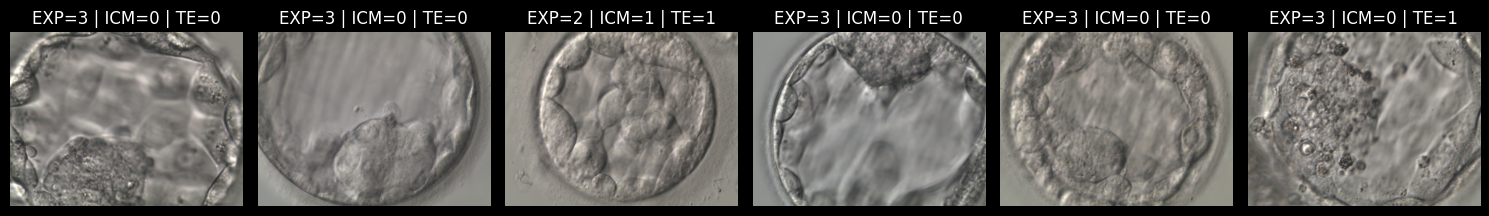

In [23]:
import matplotlib.pyplot as plt

def show_samples(df, n=6):
    """Plot n random samples with EXP, ICM, TE labels."""
    sample_df = df.sample(n=n).reset_index(drop=True)
    fig, axes = plt.subplots(1, n, figsize=(15, 5))

    for i, ax in enumerate(axes):
        row = sample_df.iloc[i]
        img = np.array(Image.open(row["path"]).convert("RGB"))
        ax.imshow(img)
        ax.set_title(f"EXP={row['expansion_label']} | ICM={row['icm_label']} | TE={row['te_label']}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# Example: show samples from validation set
show_samples(va_df, n=6)


Predicted Grades:
  Expansion: 4 (class 3)
  ICM: A (class 0)
  TE: A (class 0)

Ground Truth Grades:
  Expansion: 4
  ICM: A
  TE: A


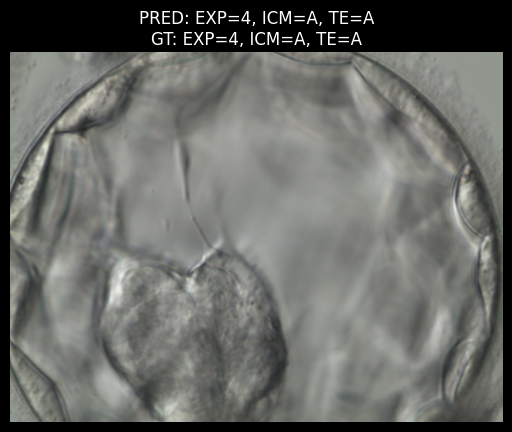

In [25]:
def predict_single_image(model, img_path, df_ref=None, transform=val_tfms, device=device):
    """
    Predict Gardner grades for a single embryo image.
    If df_ref is provided, will also show ground truth labels.
    """
    model.eval()
    img = np.array(Image.open(img_path).convert("RGB"))
    img_tensor = transform(image=img)["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        out_exp, out_icm, out_te = model(img_tensor)
        pred_exp = out_exp.argmax(1).item()
        pred_icm = out_icm.argmax(1).item()
        pred_te  = out_te.argmax(1).item()

    # Map to human-readable grades
    exp_labels = ["1","2","3","4","5","6"]  # Gardner EXP scale
    icm_labels = ["A","B","C"]
    te_labels  = ["A","B","C"]

    # Ground truth lookup (if test dataframe provided)
    if df_ref is not None:
        row = df_ref[df_ref["path"] == img_path]
        if not row.empty:
            gt_exp = exp_labels[int(row["expansion_label"].values[0])]
            gt_icm = icm_labels[int(row["icm_label"].values[0])]
            gt_te  = te_labels[int(row["te_label"].values[0])]
        else:
            gt_exp, gt_icm, gt_te = None, None, None
    else:
        gt_exp, gt_icm, gt_te = None, None, None

    # Print results
    print(f"Predicted Grades:")
    print(f"  Expansion: {exp_labels[pred_exp]} (class {pred_exp})")
    print(f"  ICM: {icm_labels[pred_icm]} (class {pred_icm})")
    print(f"  TE: {te_labels[pred_te]} (class {pred_te})")

    if gt_exp is not None:
        print("\nGround Truth Grades:")
        print(f"  Expansion: {gt_exp}")
        print(f"  ICM: {gt_icm}")
        print(f"  TE: {gt_te}")

    # Plot image with both
    plt.imshow(img)
    if gt_exp is not None:
        plt.title(f"PRED: EXP={exp_labels[pred_exp]}, ICM={icm_labels[pred_icm]}, TE={te_labels[pred_te]}\n"
                  f"GT: EXP={gt_exp}, ICM={gt_icm}, TE={gt_te}")
    else:
        plt.title(f"PRED: EXP={exp_labels[pred_exp]}, ICM={icm_labels[pred_icm]}, TE={te_labels[pred_te]}")
    plt.axis("off")
    plt.show()

# Pick a test image from gold set
img_path = df_test.iloc[10]["path"]

# Predict and compare against ground truth
predict_single_image(model, img_path, df_ref=df_test)


In [ ]:
import sys
sys.exit()